Number of stock rolls used: 87 / 100

Unique cutting patterns found:
Pattern          | Total
-------------------------
[0, 3, 0, 0, 2]  | 28   
[2, 0, 0, 0, 2]  | 26   
[0, 0, 0, 6, 2]  | 17   
[0, 0, 5, 0, 0]  | 5    
[3, 0, 0, 0, 3]  | 2    
[0, 0, 0, 0, 20] | 2    
[0, 0, 6, 0, 0]  | 1    
[0, 0, 1, 6, 0]  | 1    
[0, 4, 0, 0, 2]  | 1    
[0, 0, 3, 2, 2]  | 1    
[2, 0, 0, 0, 3]  | 1    
[1, 1, 0, 1, 2]  | 1    
[1, 0, 1, 0, 6]  | 1    

Production summary:
Item Type | Item Length | Demand | Produced | Overproduction
------------------------------------------------------------
T1        | 45          | 60     | 62       | 2
T2        | 30          | 88     | 89       | 1
T3        | 20          | 35     | 36       | 1
T4        | 15          | 110    | 112      | 2
T5        | 5           | 200    | 203      | 3


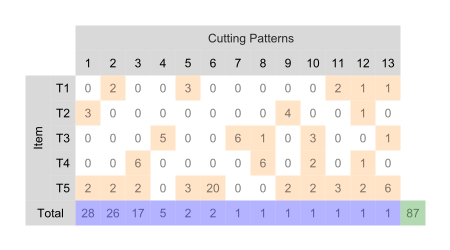

In [ ]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 6 – Graph problems
#  Section: 6.2.1 - The one-dimensional cutting stock problem
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP       # Modeling language
using HiGHS      # Solver
using DataFrames # For data handling

# Utility functions for plotting the 1D cut solution
include("utils/1dcut_utils.jl")

# Function to solve the 1D cut problem
function solve_1dcut(items, L, m)
    n = size(items, 1)  # Number of item types

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Decision variables
    @variable(model, x[1:n, 1:m] >= 0, Int) # Number of pieces of item i cut from stock roll j
    @variable(model, y[1:m], Bin) # Binary variable indicating if stock roll j is used

    # Objective: minimize the number of panels used
    @objective(model, Min, sum(y))

    # Demand satisfaction constraint 
    @constraint(model, [i in 1:n], sum(x[i,j] for j in 1:m) >= items.Demand[i])

    # Stock length capacity constraint
    @constraint(model, [j in 1:m], sum(items.Length[i] * x[i,j] for i in 1:n) <= L)

    # Only cut on used rolls constraint
    @constraint(model, [i in 1:n, j in 1:m], x[i,j] <= items.Demand[i] * y[j])

    # Solve the model
    JuMP.optimize!(model)

    # Print solution
    println("Number of stock rolls used: ", Int(JuMP.objective_value(model)), " / $m")

    # Extract solution
    y_opt = JuMP.value.(y)
    x_opt = ceil.(Int64,JuMP.value.(x))

    # Find and count each unique patterns
    unique_patterns_total = Dict{Vector{Int}, Int}()
    for i in 1:m
        if y_opt[i] > 0.5 # Only consider used rolls
            pattern = x_opt[:, i]
            if haskey(unique_patterns_total, pattern)
                unique_patterns_total[pattern] += 1
            else
                unique_patterns_total[pattern] = 1
            end
        end
    end

    # Sort the unique patterns by their counts in descending order
    unique_patterns_total = sort(collect(unique_patterns_total), by = x -> x[2], rev=true)

    # Print the unique patterns and their counts
    println("\nUnique cutting patterns found:")
    println("Pattern          | Total")
    println("-------------------------")
    for (pattern, count) in unique_patterns_total
        pattern = rpad(pattern, 16)
        count = rpad(count, 5)
        println("$(pattern) | $count")
    end

    # Print the production summary
    println("\nProduction summary:")
    println("Item Type | Item Length | Demand | Produced | Overproduction")
    println("------------------------------------------------------------")
    for i in 1:n
        item = rpad("T$(i)", 9)
        length = rpad(items.Length[i], 11)
        demand = rpad(items.Demand[i], 6)
        produced = rpad(sum(x_opt[i, j] for j in 1:m), 8)
        over = sum(x_opt[i, j] for j in 1:m) - items.Demand[i]
        println("$(item) | $(length) | $(demand) | $(produced) | $(over)")
    end

    # Plot the cutting patterns
    plot_solution(items, unique_patterns_total)
end

# Problem data
L = 100                                 # Length of each stock roll
m = 100                                 # Total of stock rolls avaiable
items = DataFrame(
    "Length" => [45, 30, 20, 15, 5],    # Length of each item type
    "Demand" => [60, 88, 35, 110, 200]  # Demand for each part type
)

# Solve the 1D cut problem
solve_1dcut(items, L, m)